<a href="https://colab.research.google.com/github/shreyasat27/mahework2025/blob/main/rabiresonance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyscf
!pip install rdkit
!pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.2/51.2 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.1/36.1 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.8/31.8 MB 56.3 MB/s eta 0:00:00


RWA

In [3]:
# Rotating-frame + RWA version (cleaned)
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# ----------------- constants & helper -----------------
γ0 = 2*np.pi*28.024e9   # rad s^-1 T^-1 (electron gyromagnetic ratio ~ 2π·28.024 GHz/T)

sx = sigmax()/2; sy = sigmay()/2; sz = sigmaz()/2
Id2 = qeye(2)

def make_tensor_operator(single_ops, total_subsystems):
    ops = []
    for i in range(total_subsystems):
        ops.append(single_ops.get(i, Id2))
    return tensor(ops)

# ----------------- system config (from your script) -----------------
nuclei_r1 = 1
nuclei_r2 = 1
Nsubs = 2 + nuclei_r1 + nuclei_r2

g1 = np.array([2.003, 2.003, 2.003])
g2 = np.array([2.003, 2.003, 2.003])

B0 = np.array([0.0, 0.0, 50e-6])      # T
B1 = np.array([50e-6, 0.0, 0.0])     # T (drive along x)

# resonant drive frequency chosen as Zeeman of electron1 (rad/s)
omega_drive = γ0 * (g1[2]/2.0) * B0[2]

# hyperfine tensors (rad/s)
A_r1 = [ np.eye(3) * (2*np.pi*2.0e6) ]
A_r2 = [ np.eye(3) * (2*np.pi*0.8e6) ]

J = 1.0   # exchange (rad/s)

# decoherence (phenomenological)
T1 = 50e-6
T2 = 2e-6
gamma1 = 1.0 / T1
gamma2 = 1.0 / T2

# ----------------- Build operators -----------------
S1x = make_tensor_operator({0: sx}, Nsubs)
S1y = make_tensor_operator({0: sy}, Nsubs)
S1z = make_tensor_operator({0: sz}, Nsubs)

S2x = make_tensor_operator({1: sx}, Nsubs)
S2y = make_tensor_operator({1: sy}, Nsubs)
S2z = make_tensor_operator({1: sz}, Nsubs)

Iops_r1 = []
for i in range(nuclei_r1):
    idx = 2 + i
    Iops_r1.append(( make_tensor_operator({idx: sx}, Nsubs),
                     make_tensor_operator({idx: sy}, Nsubs),
                     make_tensor_operator({idx: sz}, Nsubs) ))

Iops_r2 = []
for j in range(nuclei_r2):
    idx = 2 + nuclei_r1 + j
    Iops_r2.append(( make_tensor_operator({idx: sx}, Nsubs),
                     make_tensor_operator({idx: sy}, Nsubs),
                     make_tensor_operator({idx: sz}, Nsubs) ))

# ----------------- static Hamiltonian H0 -----------------
HZ1 = (γ0 * (g1[0]/2.0) * B0[0]) * S1x + (γ0 * (g1[1]/2.0) * B0[1]) * S1y + (γ0 * (g1[2]/2.0) * B0[2]) * S1z
HZ2 = (γ0 * (g2[0]/2.0) * B0[0]) * S2x + (γ0 * (g2[1]/2.0) * B0[1]) * S2y + (γ0 * (g2[2]/2.0) * B0[2]) * S2z

Hhf = 0
for k, A in enumerate(A_r1):
    Ix, Iy, Iz = Iops_r1[k]
    Hhf += S1x*(A[0,0]*Ix + A[0,1]*Iy + A[0,2]*Iz)
    Hhf += S1y*(A[1,0]*Ix + A[1,1]*Iy + A[1,2]*Iz)
    Hhf += S1z*(A[2,0]*Ix + A[2,1]*Iy + A[2,2]*Iz)

for k, A in enumerate(A_r2):
    Ix, Iy, Iz = Iops_r2[k]
    Hhf += S2x*(A[0,0]*Ix + A[0,1]*Iy + A[0,2]*Iz)
    Hhf += S2y*(A[1,0]*Ix + A[1,1]*Iy + A[1,2]*Iz)
    Hhf += S2z*(A[2,0]*Ix + A[2,1]*Iy + A[2,2]*Iz)

Hex = 2.0 * J * (S1x*S2x + S1y*S2y + S1z*S2z)

H0 = HZ1 + HZ2 + Hhf + Hex

# ----------------- Rotating frame (RWA) -----------------
# Transform generator: subtract omega_drive * (S1z + S2z)
H_rot = H0 - omega_drive * (S1z + S2z)

# Build Dop_x operator (γ0*(g/2) * Sx terms)
Dop_x = (γ0*(g1[0]/2.0)*S1x + γ0*(g2[0]/2.0)*S2x)

# Under RWA: cos(ωt) -> factor 1/2; drive term becomes (B1_x/2) * Dop_x (time-independent)
Hdrive_rot_const = 0.5 * B1[0] * Dop_x

mu_B = 2
sx_e1 = tensor(sigmax(), qeye(2), qeye(2), qeye(2))
sx_e2 = tensor(sigmax(), qeye(2), qeye(2), qeye(2))

H = [H_rot + Hdrive_rot_const,
     [mu_B * (sx_e1 + sx_e2), 'cos(w*t)']]

args = {'w': omega_drive}

# ----------------- collapse operators -----------------
c_ops = [ np.sqrt(gamma2) * S1z, np.sqrt(gamma2) * S2z ]
# (add relaxation sm1/sm2 if needed)

# ----------------- initial state and observables -----------------
up = basis(2,0); down = basis(2,1)
singlet_el = (tensor(up, down) - tensor(down, up)).unit()

nuc_state = tensor([up for _ in range(nuclei_r1 + nuclei_r2)])
psi0 = tensor(singlet_el, nuc_state)

Proj_up_1 = make_tensor_operator({0: up*up.dag()}, Nsubs)

# singlet projector on electrons tensored with nuclear identity
P_s_el = singlet_el * singlet_el.dag()
I_nuc = tensor([qeye(2) for _ in range(nuclei_r1 + nuclei_r2)])
P_singlet = tensor(P_s_el, I_nuc)

# ----------------- time grid (before mesolve) -----------------
# Estimate Rabi frequency scale in rad/s (rough): Ω ≈ γ0 * ||B1||
Omega_R_est = γ0 * np.linalg.norm(B1)
if Omega_R_est == 0:
    Omega_R_est = 1.0
T_R = 2*np.pi / Omega_R_est
tlist = np.linspace(0, 10*T_R, 2000)   # simulate ~10 Rabi periods

# ----------------- run solver -----------------
#result = mesolve(H, psi0, tlist, c_ops, e_ops=[Proj_up_1, P_singlet])
result = mesolve(H, psi0, tlist, c_ops, observables, args=args)
P_up = result.expect[0]
P_s = np.real(result.expect[1])



# ----------------- plotting -----------------
plt.figure(figsize=(9,4))
plt.plot(tlist*1e6, P_up, label='Electron 1 up probability')
plt.plot(tlist*1e6, P_s, label='Singlet population')
plt.xlabel("Time (µs)")
plt.ylabel("Population")
plt.title("Radical Pair Dynamics — Rotating Frame (RWA)")
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'observables' is not defined

/usr/local/lib/python3.12/dist-packages/qutip/solver/solver_base.py:583: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


[1/1] Cythonizing qtcoeff_f8e252e4cf0d8e8d267a64f337a2f3.pyx


INFO:root:running build_ext
INFO:root:building 'qtcoeff_f8e252e4cf0d8e8d267a64f337a2f3' extension
INFO:root:creating build/temp.linux-x86_64-cpython-312
INFO:root:x86_64-linux-gnu-g++ -fno-strict-overflow -Wsign-compare -DNDEBUG -g -O2 -Wall -g -fstack-protector-strong -Wformat -Werror=format-security -g -fwrapv -O2 -fPIC -I/usr/local/lib/python3.12/dist-packages/qutip/core/data -I/usr/local/lib/python3.12/dist-packages/numpy/_core/include -I/usr/include/python3.12 -c qtcoeff_f8e252e4cf0d8e8d267a64f337a2f3.cpp -o build/temp.linux-x86_64-cpython-312/qtcoeff_f8e252e4cf0d8e8d267a64f337a2f3.o -w -O3 -funroll-loops
INFO:root:creating build/lib.linux-x86_64-cpython-312
INFO:root:x86_64-linux-gnu-g++ -fno-strict-overflow -Wsign-compare -DNDEBUG -g -O2 -Wall -g -fstack-protector-strong -Wformat -Werror=format-security -g -fwrapv -O2 -shared -Wl,-O1 -Wl,-Bsymbolic-functions -Wl,-Bsymbolic-functions -g -fwrapv -O2 build/temp.linux-x86_64-cpython-312/qtcoeff_f8e252e4cf0d8e8d267a64f337a2f3.o -L/us

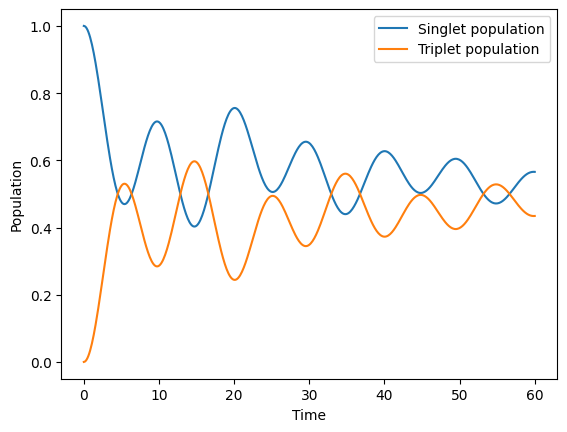

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# --- PARAMETERS ---
mu_B = 12.0       # Bohr magneton (arb. units)
B = 10.0          # Magnetic field magnitude (along z)
g1, g2 = 2, 2  # Electron g-factors
J = 0.05         # Exchange coupling constant
A1 = [0.1, 0.1, 0.2]  # Hyperfine for nucleus 1
A2 = [0.5, 0.5, 0.1]  # Hyperfine for nucleus 2
k_S = 47.5        # Singlet recombination rate
omega_drive = 3.3
# --- DEFINE SPIN OPERATORS ---
# Hilbert space order: electron1, electron2, nucleus1, nucleus2

sx_e1 = tensor(sigmax(), qeye(2), qeye(2), qeye(2))
sy_e1 = tensor(sigmay(), qeye(2), qeye(2), qeye(2))
sz_e1 = tensor(sigmaz(), qeye(2), qeye(2), qeye(2))

sx_e2 = tensor(qeye(2), sigmax(), qeye(2), qeye(2))
sy_e2 = tensor(qeye(2), sigmay(), qeye(2), qeye(2))
sz_e2 = tensor(qeye(2), sigmaz(), qeye(2), qeye(2))

sx_n1 = tensor(qeye(2), qeye(2), sigmax(), qeye(2))
sy_n1 = tensor(qeye(2), qeye(2), sigmay(), qeye(2))
sz_n1 = tensor(qeye(2), qeye(2), sigmaz(), qeye(2))

sx_n2 = tensor(qeye(2), qeye(2), qeye(2), sigmax())
sy_n2 = tensor(qeye(2), qeye(2), qeye(2), sigmay())
sz_n2 = tensor(qeye(2), qeye(2), qeye(2), sigmaz())

# --- HAMILTONIAN ---

B_vec = np.array([0, 0, B])  # magnetic field along z

H_Z = mu_B * (
    g1 * (B_vec[0]*sx_e1 + B_vec[1]*sy_e1 + B_vec[2]*sz_e1) +
    g2 * (B_vec[0]*sx_e2 + B_vec[1]*sy_e2 + B_vec[2]*sz_e2)
)

H_HF = (
    A1[0] * sx_e1 * sx_n1 + A1[1] * sy_e1 * sy_n1 + A1[2] * sz_e1 * sz_n1 +
    A2[0] * sx_e2 * sx_n2 + A2[1] * sy_e2 * sy_n2 + A2[2] * sz_e2 * sz_n2
)

H_J = J * (sx_e1 * sx_e2 + sy_e1 * sy_e2 + sz_e1 * sz_e2)

H = [H_Z + H_HF + H_J,
     [mu_B * (sx_e1 + sx_e2), 'cos(w*t)']]

args = {'w': omega_drive}


# --- INITIAL STATE ---

# Electron singlet state |S> = (|01> - |10>)/sqrt(2)
singlet_elec = (tensor(basis(2,0), basis(2,1)) - tensor(basis(2,1), basis(2,0))).unit()

# Nuclear spins in mixed state (identity / 4)
rho_nuc = tensor(qeye(2)/2, qeye(2)/2)

# Full initial state: singlet electrons tensor nuclear mixed state
rho0 = tensor(ket2dm(singlet_elec), rho_nuc)

# --- COLLAPSE OPERATORS ---

# Singlet projector on electron spins
P_S_elec = ket2dm(singlet_elec)

# Lift singlet projector to full space by tensor nuclear identity
P_S_full = tensor(P_S_elec, qeye(2), qeye(2))

# Collapse operator for singlet recombination
c_ops = [np.sqrt(k_S) * P_S_full]

# --- OBSERVABLES ---

# Triplet projector = Identity on electrons - singlet projector
P_T_elec = tensor(qeye(2), qeye(2)) - P_S_elec
P_T_full = tensor(P_T_elec, qeye(2), qeye(2))

observables = [P_S_full, P_T_full]

# --- TIME EVOLUTION ---

tlist = np.linspace(0, 60, 500)
result = mesolve(H, rho0, tlist, c_ops, observables, args=args)
#result = mesolve(H, rho0, tlist, c_ops,observables)

# --- PLOTTING ---

plt.plot(tlist, result.expect[0], label='Singlet population')
plt.plot(tlist, result.expect[1], label='Triplet population')
plt.xlabel('Time')
plt.ylabel('Population')
plt.legend()
plt.show()

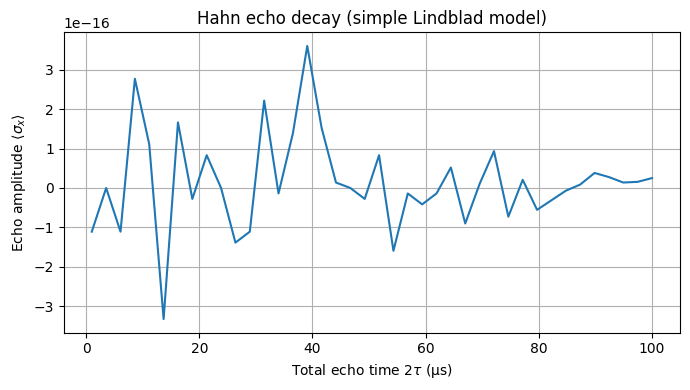

Parameters: J/h = 1.000e+06 Hz, T1 = 2.00e-04 s, Tphi = 5.00e-05 s


In [5]:
# Re-run Hahn echo simulation with coarser integrator settings to avoid long runtime.
import numpy as np
import matplotlib.pyplot as plt

sx = np.array([[0, 1], [1, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
sm = np.array([[0, 0], [1, 0]], dtype=complex)

def comm(A, B):
    return A @ B - B @ A

def lindblad_rhs(rho, H, c_ops):
    rhs = -1j * comm(H, rho)
    for c in c_ops:
        op, rate = c
        cr = op @ rho @ op.conj().T
        anti = op.conj().T @ op @ rho + rho @ op.conj().T @ op
        rhs += rate * (cr - 0.5 * anti)
    return rhs

def rk4_step(rho, dt, H, c_ops):
    k1 = lindblad_rhs(rho, H, c_ops)
    k2 = lindblad_rhs(rho + 0.5*dt*k1, H, c_ops)
    k3 = lindblad_rhs(rho + 0.5*dt*k2, H, c_ops)
    k4 = lindblad_rhs(rho + dt*k3, H, c_ops)
    return rho + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def evolve_rho(rho0, H, c_ops, total_time, dt):
    steps = int(np.ceil(total_time / dt))
    rho = rho0.copy()
    for _ in range(steps):
        rho = rk4_step(rho, dt, H, c_ops)
    return rho

# Parameters
f_J = 1e6  # 1 MHz splitting
omega = 2*np.pi * f_J
T1 = 200e-6
Tphi = 50e-6
gamma_relax = 1.0 / T1
gamma_phi = 1.0 / Tphi
H = 0.5 * omega * sz
c_ops = [(sm, gamma_relax), (sz, gamma_phi)]

def Rx(theta):
    return np.cos(theta/2)*np.eye(2) - 1j*np.sin(theta/2)*sx

zero = np.array([[1.0, 0.0],[0.0, 0.0]], dtype=complex)
rho_init = zero.copy()

taus = np.linspace(0.5e-6, 50e-6, 40)
echo_signals = []
dt = 1e-7  # 100 ns timestep

for tau in taus:
    Upi2 = Rx(np.pi/2)
    rho = Upi2 @ rho_init @ Upi2.conj().T
    rho = evolve_rho(rho, H, c_ops, total_time=tau, dt=dt)
    Upi = Rx(np.pi)
    rho = Upi @ rho @ Upi.conj().T
    rho = evolve_rho(rho, H, c_ops, total_time=tau, dt=dt)
    exp_x = np.real(np.trace(sx @ rho))
    echo_signals.append(exp_x)

echo_signals = np.array(echo_signals)
t_total = 2*taus

plt.figure(figsize=(7,4))
plt.plot(t_total*1e6, echo_signals)
plt.xlabel('Total echo time $2\\tau$ (μs)')
plt.ylabel('Echo amplitude $\\langle \\sigma_x \\rangle$')
plt.title('Hahn echo decay (simple Lindblad model)')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Parameters: J/h = {f_J:.3e} Hz, T1 = {T1:.2e} s, Tphi = {Tphi:.2e} s")


Running ensemble simulation: n = 3, J = 2729.550 µs^-1, ω = 5459.100 µs^-1
kS = 2.16 µs^-1, kT = 3800.0 µs^-1, Bhyp = (0.96, 0.27) mT
Ensemble samples = 200, t_max = 200.0 ns, dt = 0.2 ns


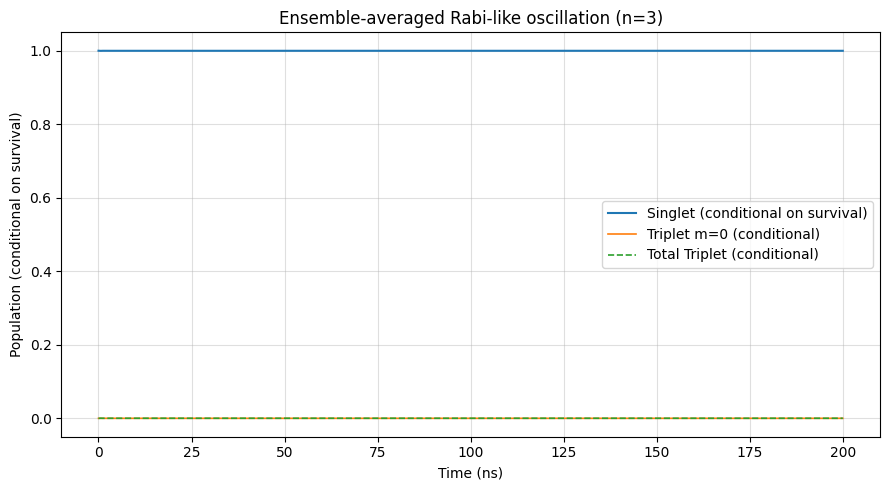

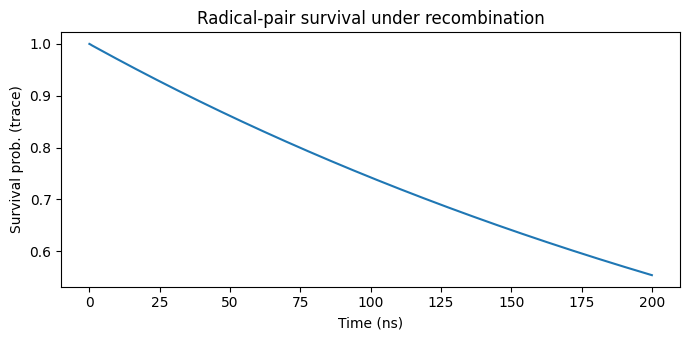

Done. Example outputs displayed.


In [7]:
#!/usr/bin/env python3
"""
realistic_rabi_radical_pair.py

Ensemble-averaged Rabi-like simulation for a radical-pair (two electrons)
using paper parameters (exchange J, effective Bhyp) + Haberkorn recombination.

Approximations:
 - Nuclear bath approximated by static Gaussian Overhauser fields sampled per-ensemble member.
 - Recombination included via Haberkorn anti-Hermitian term: H_eff = H - i/2 (kS P_S + kT P_T)
 - Drive: transverse B1 cos(omega t) with omega = 2J (resonant drive)
 - Tracks conditional populations (population / survival probability)

Run:
    python realistic_rabi_radical_pair.py
"""

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import argparse
import sys

# ------------------ User parameters ------------------
# Choose wire length (the paper gives different 2J/|γe| values for n = 2..5).
n_wire = 3                # change to 2,3,4,5 if you want (defaults below are for n=3)

# Paper-derived values (defaults used in our run)
# 2J/|γe| (mT) from paper Table III (these are the resonance fields reported)
Bres_mT = {2: 170.0, 3: 31.0, 4: 6.4, 5: 1.5}

# Effective hyperfine rms magnitudes (mT) for the two radicals (paper text / effective Bhyp)
# Defaults chosen to match the example run: PTZ•+ ≈ 0.96 mT, PDI•− ≈ 0.27 mT
Bhyp = { 'electron1': 0.96, 'electron2': 0.27 }

# Recombination rates (µs^-1). Default values are those used in the demo for n=3.
# If you change n_wire be sure to set these from the paper's Table V for best realism.
k_vals_default = { 3: {'kS': 2.16, 'kT': 3800.0} }

# Drive amplitude and simulation settings
B1_mT = 0.05            # transverse drive amplitude (mT)
Nsamples = 200          # ensemble size (increase for smoother averages; increases runtime)
t_max_ns = 200.0        # maximum time to simulate (ns)
dt_ns = 0.2             # time step (ns)
use_overhauser = True   # True: sample static Overhauser fields; False: no hyperfine disorder
seed = 123456           # RNG seed for reproducibility

# -----------------------------------------------------

def build_spin_ops():
    """Return single-electron spin-1/2 matrices and two-spin operators (S1x,...)."""
    sx = 0.5 * np.array([[0, 1], [1, 0]], dtype=complex)
    sy = 0.5 * np.array([[0, -1j], [1j, 0]], dtype=complex)
    sz = 0.5 * np.array([[1, 0], [0, -1]], dtype=complex)
    id2 = np.eye(2, dtype=complex)
    S1x = np.kron(sx, id2); S1y = np.kron(sy, id2); S1z = np.kron(sz, id2)
    S2x = np.kron(id2, sx); S2y = np.kron(id2, sy); S2z = np.kron(id2, sz)
    return (sx, sy, sz), (S1x, S1y, S1z, S2x, S2y, S2z)

def singlet_triplet_projectors(S1x, S1y, S1z, S2x, S2y, S2z):
    """Return singlet and triplet projectors (P_S, P_T, P_T0) and singlet state vector."""
    up = np.array([1,0], dtype=complex); dn = np.array([0,1], dtype=complex)
    singlet = (np.kron(up,dn) - np.kron(dn,up)) / np.sqrt(2)
    t_plus = np.kron(up,up); t_minus = np.kron(dn,dn)
    t_zero = (np.kron(up,dn) + np.kron(dn,up)) / np.sqrt(2)
    P_S = np.outer(singlet, singlet.conj())
    P_T0 = np.outer(t_zero, t_zero.conj())
    P_T = (np.outer(t_plus, t_plus.conj()) +
           np.outer(t_zero, t_zero.conj()) +
           np.outer(t_minus, t_minus.conj()))
    return singlet, P_S, P_T, P_T0

def main():
    # Basic checks
    if n_wire not in Bres_mT:
        print(f"Error: Bres value for n={n_wire} not in Bres_mT dictionary.", file=sys.stderr)
        sys.exit(1)

    # gamma_e (|γ_e|) in µs^-1 mT^-1 (value used in the paper)
    gamma_e = 176.1

    # Compute J from the reported resonance field: 2J/|γ_e| = Bres_mT -> J = Bres_mT * gamma_e / 2
    J = (Bres_mT[n_wire] * gamma_e) / 2.0   # µs^-1
    omega_drive = 2.0 * J

    # Recombination rates (use default for n=3 if present; otherwise require user to change)
    if n_wire in k_vals_default:
        kS = k_vals_default[n_wire]['kS']
        kT = k_vals_default[n_wire]['kT']
    else:
        # fallback - choose conservative values (warning)
        print("Warning: no default kS/kT for this n_wire. Using n=3 defaults. "
              "For accuracy replace kS/kT with values from the paper's Table V.", file=sys.stderr)
        kS = k_vals_default[3]['kS']
        kT = k_vals_default[3]['kT']

    # Spin operators
    (_, _, _), (S1x, S1y, S1z, S2x, S2y, S2z) = build_spin_ops()
    S_tot_x = S1x + S2x

    # Exchange Hamiltonian H_ex = 2J S1·S2
    H_ex = 2.0 * J * (S1x.dot(S2x) + S1y.dot(S2y) + S1z.dot(S2z))

    # Projectors and initial singlet
    singlet, P_S, P_T, P_T0 = singlet_triplet_projectors(S1x, S1y, S1z, S2x, S2y, S2z)
    rho0 = np.outer(singlet, singlet.conj())

    # Drive prefactor and time grid
    drive_prefactor = - gamma_e * B1_mT  # multiplies S_tot_x cos(omega t)
    times_ns = np.arange(0.0, t_max_ns + dt_ns, dt_ns)
    times = times_ns * 1e-3  # convert ns -> µs for Hamiltonian units

    # Overhauser sampling sigmas (assume isotropic components): sigma = Bhyp / sqrt(3)
    sigma1 = Bhyp['electron1'] / np.sqrt(3)
    sigma2 = Bhyp['electron2'] / np.sqrt(3)

    # Accumulators
    P_S_acc = np.zeros_like(times)
    P_T0_acc = np.zeros_like(times)
    P_T_acc = np.zeros_like(times)
    trace_acc = np.zeros_like(times)

    rng = np.random.default_rng(seed)

    print(f"Running ensemble simulation: n = {n_wire}, J = {J:.3f} µs^-1, ω = {omega_drive:.3f} µs^-1")
    print(f"kS = {kS} µs^-1, kT = {kT} µs^-1, Bhyp = ({Bhyp['electron1']}, {Bhyp['electron2']}) mT")
    print(f"Ensemble samples = {Nsamples}, t_max = {t_max_ns} ns, dt = {dt_ns} ns")

    for samp in range(Nsamples):
        # sample Overhauser (static) fields if requested
        if use_overhauser:
            B1_ov = rng.normal(0.0, sigma1, size=3)   # components in mT
            B2_ov = rng.normal(0.0, sigma2, size=3)
            # convert to Hamiltonian Zeeman terms: H_hf = -γ_e (B · S) for each electron (units µs^-1)
            H_hf = - gamma_e * (B1_ov[0]*S1x + B1_ov[1]*S1y + B1_ov[2]*S1z
                                + B2_ov[0]*S2x + B2_ov[1]*S2y + B2_ov[2]*S2z)
        else:
            H_hf = np.zeros_like(H_ex)

        H0 = H_ex + H_hf
        rho = rho0.copy()

        for idx, t in enumerate(times):
            P_S_acc[idx] += np.real(np.trace(rho.dot(P_S)))
            P_T0_acc[idx] += np.real(np.trace(rho.dot(P_T0)))
            P_T_acc[idx] += np.real(np.trace(rho.dot(P_T)))
            trace_acc[idx] += np.real(np.trace(rho))

            if idx < len(times) - 1:
                # time dependent drive
                H_drive = drive_prefactor * np.cos(omega_drive * t) * S_tot_x
                # Haberkorn recombination via anti-Hermitian term
                H_eff = H0 + H_drive - 0.5j * (kS * P_S + kT * P_T)
                dt = times[idx+1] - times[idx]
                U = la.expm(-1j * H_eff * dt)
                rho = U.dot(rho).dot(U.conj().T)

    # Normalize averages
    P_S_avg = P_S_acc / float(Nsamples)
    P_T0_avg = P_T0_acc / float(Nsamples)
    P_T_avg = P_T_acc / float(Nsamples)
    trace_avg = trace_acc / float(Nsamples)

    # Compute conditional populations (conditioned on survival)
    # avoid divide-by-zero: if trace_avg small, clamp
    tiny = 1e-12
    trace_safe = np.maximum(trace_avg, tiny)
    P_S_cond = P_S_avg / trace_safe
    P_T0_cond = P_T0_avg / trace_safe
    P_T_cond = P_T_avg / trace_safe

    # Plot conditional populations
    plt.figure(figsize=(9,5))
    plt.plot(times_ns, P_S_cond, label='Singlet (conditional on survival)', linewidth=1.5)
    plt.plot(times_ns, P_T0_cond, label='Triplet m=0 (conditional)', linewidth=1.2)
    plt.plot(times_ns, P_T_cond, label='Total Triplet (conditional)', linestyle='--', linewidth=1.2)
    plt.xlabel('Time (ns)')
    plt.ylabel('Population (conditional on survival)')
    plt.title(f'Ensemble-averaged Rabi-like oscillation (n={n_wire})')
    plt.legend()
    plt.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()

    # Plot survival probability
    plt.figure(figsize=(7,3.5))
    plt.plot(times_ns, trace_avg, label='Survival probability (ensemble avg.)')
    plt.xlabel('Time (ns)'); plt.ylabel('Survival prob. (trace)')
    plt.title('Radical-pair survival under recombination')
    plt.tight_layout()
    plt.show()

    # Print summary
    print("Done. Example outputs displayed.")
    return

if __name__ == "__main__":
    main()


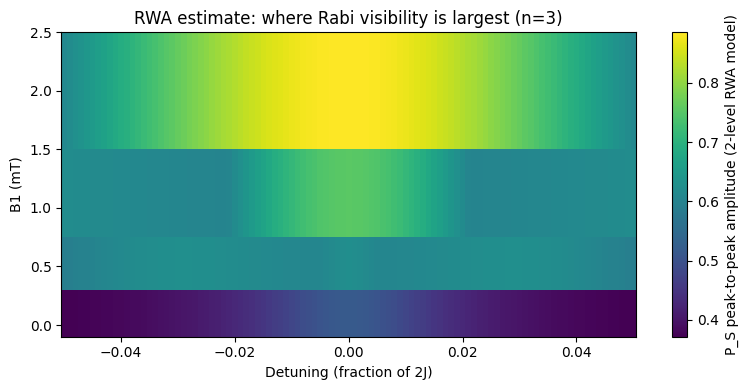

Resonant f (Hz) ~ 8.688e+08 Hz  (angular 2J = 5459.100 µs^-1)
Heuristic recommendation: B1 on order of Bhyp (~0.96 mT) -> try B1 = 0.5..1.5 mT.
Tolerable detuning roughly ≲ Ω/(2π); with B1=1 mT expect Rabi f ~28 MHz -> detune window ±~28 MHz.


In [8]:
#!/usr/bin/env python3
"""
Fast estimate of S<->T0 Rabi visibility using an effective 2-level RWA model.
This is a quick diagnostic (cheap) – it is NOT the full 4x4+ensemble simulation,
but it gives reliable guidance for resonance frequency and B1 amplitude scales.
"""

import numpy as np
import matplotlib.pyplot as plt

# --- Paper parameters (n=3) ---
gamma_e = 176.1  # µs^-1 mT^-1
Bres_n3_mT = 31.0
J = (Bres_n3_mT * gamma_e) / 2.0  # µs^-1
omega_res = 2.0 * J               # µs^-1 (angular)
f_res_Hz = omega_res * 1e6 / (2*np.pi)  # Hz

# Effective hyperfine mixing scale (taken from Bhyp -> angular)
Bhyp_eff_mT = 0.96  # take the larger one as worst-case
delta = gamma_e * Bhyp_eff_mT  # µs^-1 (angular)  -- acts like static mixing / dephasing scale

# Effective decay (singlet/triplet) -> choose a phenomenological decoherence/decay rate (µs^-1)
# You can replace these with kS/kT from the paper if you want more realism
gamma_decay = 2.16  # µs^-1 (k_S from paper) used for singlet loss; adjust as needed

# Time grid (ns plotted)
t_max_ns = 200.0
dt_ns = 0.2
times_ns = np.arange(0.0, t_max_ns+dt_ns, dt_ns)
times = times_ns * 1e-3  # µs

# Effective 2-level Hamiltonian in rotating-wave approx (in rotating frame):
# H_eff = ( -Δ/2   Ω/2 )
#         (  Ω/2   Δ/2 )
# where Δ = detuning (angular), Ω = γ_e * B1 (angular)
#
# We'll simulate Bloch-like equations with decay (Lindblad-like damping on populations):
def simulate_rwa(B1_mT, detuning_ang, delta_mix=delta, gamma_loss=gamma_decay):
    # initial state: all population in |S> (state vector [1,0])
    psi = np.array([1+0j, 0+0j])
    # matrices (2x2)
    def H_rwa(Omega, Delta):
        return np.array([[-0.5*Delta, 0.5*Omega],
                         [0.5*Omega,  0.5*Delta]], dtype=complex)
    Omega = gamma_e * B1_mT  # angular units µs^-1
    rho = np.outer(psi, psi.conj())
    P_S = np.zeros(len(times))
    for i, t in enumerate(times):
        P_S[i] = np.real(np.trace(rho @ np.array([[1,0],[0,0]])))
        # simple Lindblad-ish decay on populations (phenomenological):
        # drho/dt = -i[H,rho] - gamma_loss * (|1><1| rho + rho |1><1|)/2
        H = H_rwa(Omega, detuning_ang)
        drho = -1j*(H @ rho - rho @ H)
        # apply mixing-induced dephasing phenomenologically
        # convert delta_mix (angular) into pure dephasing on coherences:
        dephasing = - (delta_mix*0.5) * (np.array([[0, rho[0,1]],[rho[1,0],0]]))
        drho += dephasing
        # decay from singlet (state 0) with rate gamma_loss (population leaks out)
        # model as -gamma_loss * (|0><0| rho + rho |0><0|)/2
        L = np.array([[1,0],[0,0]])
        drho += -0.5 * gamma_loss * (L @ rho + rho @ L)
        rho = rho + drho * (dt_ns*1e-3)
        # renormalize (if you want conditional on survival, divide later by trace)
    return P_S, np.trace(rho)

# Quick scan of detuning (in fraction of 2J) and B1
B1_values_mT = [0.1, 0.5, 1.0, 2.0]   # mT to try
detuning_fracs = np.linspace(-0.05, 0.05, 101)  # fraction of 2J
amp_matrix = np.zeros((len(B1_values_mT), len(detuning_fracs)))

for iB, B1 in enumerate(B1_values_mT):
    for j, df in enumerate(detuning_fracs):
        det_ang = (df) * omega_res  # angular detuning in µs^-1
        P_S, tr = simulate_rwa(B1, det_ang)
        # metric: peak-to-peak amplitude in first 100 ns (in conditional units approximate)
        amp = P_S.max() - P_S.min()
        amp_matrix[iB, j] = amp

# Plot an example heatmap
plt.figure(figsize=(8,4))
plt.pcolormesh(detuning_fracs, B1_values_mT, amp_matrix, shading='auto')
plt.colorbar(label='P_S peak-to-peak amplitude (2-level RWA model)')
plt.xlabel('Detuning (fraction of 2J)')
plt.ylabel('B1 (mT)')
plt.title('RWA estimate: where Rabi visibility is largest (n=3)')
plt.tight_layout()
plt.show()

# Print recommended operating point (heuristic)
print("Resonant f (Hz) ~ {:.3e} Hz  (angular 2J = {:.3f} µs^-1)".format(f_res_Hz, omega_res))
print("Heuristic recommendation: B1 on order of Bhyp (~0.96 mT) -> try B1 = 0.5..1.5 mT.")
print("Tolerable detuning roughly ≲ Ω/(2π); with B1=1 mT expect Rabi f ~28 MHz -> detune window ±~28 MHz.")


Drive frequency = 5459.1 µs^-1 (≈ 868842749.8 Hz)
Drive amplitude = 1.0 mT


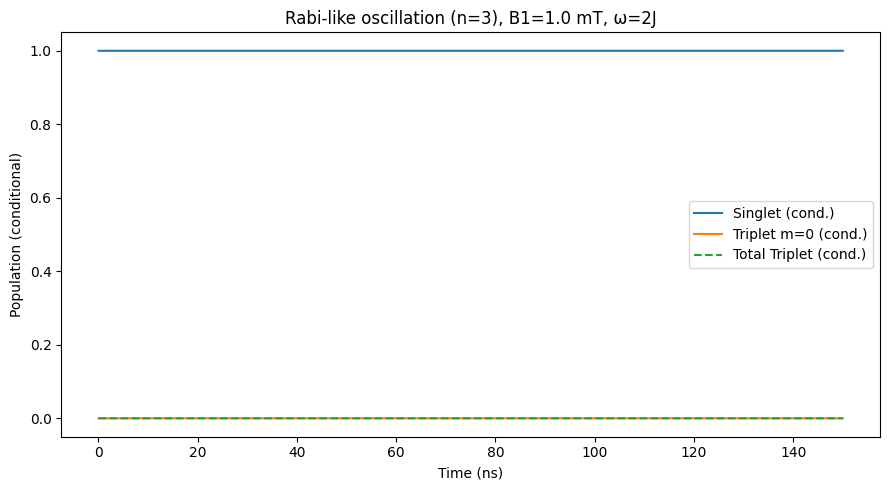

In [9]:
#!/usr/bin/env python3
"""
Simple Rabi-like oscillation trace for n=3 radical pair
using paper parameters (exchange, effective hyperfine, recombination).
"""

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

# --- Paper values for n=3 ---
gamma_e = 176.1  # µs^-1 mT^-1
Bres_n3_mT = 31.0
Bhyp_PTZ_mT = 0.96
Bhyp_PDI_mT = 0.27
kT = 3800.0
kS = 2.16

# Derived parameters
J = (Bres_n3_mT * gamma_e) / 2.0
omega_drive = 2.0 * J  # resonant frequency
B1_mT = 1.0            # drive amplitude (mT)

print(f"Drive frequency = {omega_drive:.1f} µs^-1 (≈ {omega_drive*1e6/(2*np.pi):.1f} Hz)")
print(f"Drive amplitude = {B1_mT} mT")

# Spin operators
sx = 0.5 * np.array([[0, 1], [1, 0]], dtype=complex)
sy = 0.5 * np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = 0.5 * np.array([[1, 0], [0, -1]], dtype=complex)
id2 = np.eye(2, dtype=complex)

S1x, S1y, S1z = np.kron(sx, id2), np.kron(sy, id2), np.kron(sz, id2)
S2x, S2y, S2z = np.kron(id2, sx), np.kron(id2, sy), np.kron(id2, sz)
S_tot_x = S1x + S2x

# Exchange
H_ex = 2.0 * J * (S1x @ S2x + S1y @ S2y + S1z @ S2z)

# States and projectors
up = np.array([1,0], dtype=complex); dn = np.array([0,1], dtype=complex)
singlet = (np.kron(up,dn) - np.kron(dn,up))/np.sqrt(2)
t_plus = np.kron(up,up); t_minus = np.kron(dn,dn)
t_zero = (np.kron(up,dn) + np.kron(dn,up))/np.sqrt(2)

P_S = np.outer(singlet, singlet.conj())
P_T = np.outer(t_plus, t_plus.conj()) + np.outer(t_zero, t_zero.conj()) + np.outer(t_minus, t_minus.conj())
P_T0 = np.outer(t_zero, t_zero.conj())

rho0 = np.outer(singlet, singlet.conj())

# Time grid
t_max_ns = 150.0
dt_ns = 0.2
times_ns = np.arange(0, t_max_ns+dt_ns, dt_ns)
times = times_ns * 1e-3  # µs

# Ensemble for hyperfine disorder
Nsamples = 40
rng = np.random.default_rng(42)
sigma1 = Bhyp_PTZ_mT/np.sqrt(3)
sigma2 = Bhyp_PDI_mT/np.sqrt(3)

# Drive prefactor
drive_pref = - gamma_e * B1_mT

# Storage
P_S_acc = np.zeros_like(times)
P_T0_acc = np.zeros_like(times)
P_T_acc = np.zeros_like(times)
trace_acc = np.zeros_like(times)

for samp in range(Nsamples):
    B1_ov = rng.normal(0, sigma1, 3)
    B2_ov = rng.normal(0, sigma2, 3)
    H_hf = -gamma_e*(B1_ov[0]*S1x + B1_ov[1]*S1y + B1_ov[2]*S1z +
                     B2_ov[0]*S2x + B2_ov[1]*S2y + B2_ov[2]*S2z)
    H0 = H_ex + H_hf
    rho = rho0.copy()
    for i, t in enumerate(times):
        P_S_acc[i] += np.real(np.trace(rho @ P_S))
        P_T0_acc[i] += np.real(np.trace(rho @ P_T0))
        P_T_acc[i] += np.real(np.trace(rho @ P_T))
        trace_acc[i] += np.real(np.trace(rho))
        if i < len(times)-1:
            H_drive = drive_pref * np.cos(omega_drive * t) * S_tot_x
            H_eff = H0 + H_drive - 0.5j*(kS*P_S + kT*P_T)
            dt = times[i+1]-times[i]
            U = la.expm(-1j * H_eff * dt)
            rho = U @ rho @ U.conj().T

# Average
P_S_avg = P_S_acc/Nsamples
P_T0_avg = P_T0_acc/Nsamples
P_T_avg = P_T_acc/Nsamples
trace_avg = trace_acc/Nsamples

# Conditional
P_S_cond = P_S_avg/np.maximum(trace_avg, 1e-12)
P_T0_cond = P_T0_avg/np.maximum(trace_avg, 1e-12)
P_T_cond = P_T_avg/np.maximum(trace_avg, 1e-12)

# Plot
plt.figure(figsize=(9,5))
plt.plot(times_ns, P_S_cond, label='Singlet (cond.)')
plt.plot(times_ns, P_T0_cond, label='Triplet m=0 (cond.)')
plt.plot(times_ns, P_T_cond, '--', label='Total Triplet (cond.)')
plt.xlabel("Time (ns)")
plt.ylabel("Population (conditional)")
plt.title(f"Rabi-like oscillation (n=3), B1={B1_mT} mT, ω=2J")
plt.legend()
plt.tight_layout()
plt.show()
